# SOCIAL NETWORK ANALYSIS: CORSO INTRODUTTIVO

### TC CSArs Calanna

In [160]:
# importa librerie
from itertools import permutations
import numpy as np
import pandas as pd
import networkx as nx
import networkx.algorithms.connectivity as nxconn
from networkx.algorithms import community as nxcomm
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [192]:
# opzioni di base
FIG_SIZE = (10,8)
NODE_SIZE=450
SEED = 42
K_VALUE = .2

BASE_OPTIONS = {
    "node_size": NODE_SIZE,
    "node_color": "white",
    "edgecolors": "black",
    "linewidths": 1,
    "width": 1,
}

NODE_OPTIONS = {
    "node_size": NODE_SIZE,
    "node_color": "white",
    "edgecolors": "black",
}

# INTRO

L'analisi delle reti sociali (SNA) consente l'indagine delle strutture sociali attraverso l'uso delle reti e della teoria dei grafi.<br />La SNA caratterizza i gruppi sociali in termini di nodi (attori, persone) e di collegamenti tra nodi (relazioni, interazioni) 

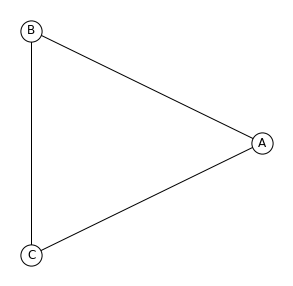

In [162]:
# ESEMPIO DI UNDIRECTED NETWORK (NETWORK NON ORIENTATO)
fig, ax = plt.subplots(figsize=(5,5))
ax.axis('off')

alpha = "ABCA"
nodes = [(x, alpha[idx+1]) for idx, x in enumerate(alpha[:-1])]

Gu = nx.Graph()
Gu.add_edges_from(nodes)
pos = nx.circular_layout(Gu)
nx.draw_networkx(Gu, pos, **BASE_OPTIONS, ax=ax);

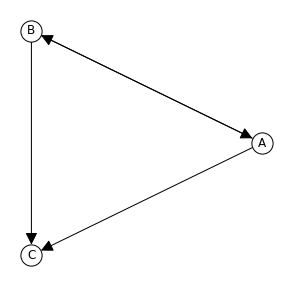

In [239]:
# ESEMPIO DI DIRECTED NETWORK (NETWORK ORIENTATO)
fig, ax = plt.subplots(figsize=(5,5))
ax.axis('off')

alpha = "ABC"
nodes = list(permutations(alpha,2))

Gd = nx.DiGraph()
Gd.add_edges_from(nodes[:-2])
pos = nx.circular_layout(Gd)
options = dict(**BASE_OPTIONS)
options.update({ "arrowsize": 25 })
nx.draw_networkx(Gd, pos, **options, ax=ax);

# ESERCITAZIONE

In [236]:
# NETWORK ESERCITAZIONE
# caricato da file esterno
Ge = nx.read_edgelist("Ge.edgelist")

## 1. VISUALIZZAZIONE DEL NETWORK

### 1.1 LAYOUT CIRCOLARE

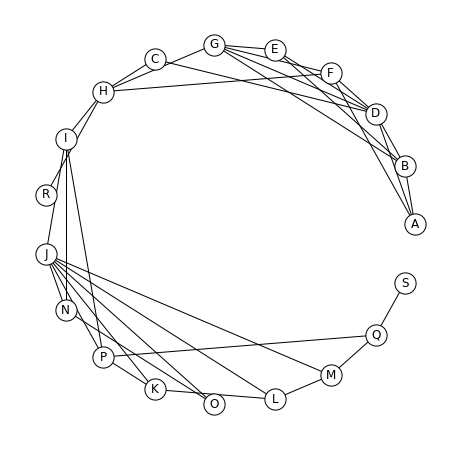

In [242]:
# VISUALIZZAZIONE LAYOUT CIRCOLARE
fig, ax = plt.subplots(figsize=(8,8))
ax.axis('off')

# output network
nx.draw_networkx(Ge, pos=nx.circular_layout(Ge), **BASE_OPTIONS, ax=ax)

### 1.2 LAYOUT FORCE-DIRECTED (A CAMPO DI FORZA)

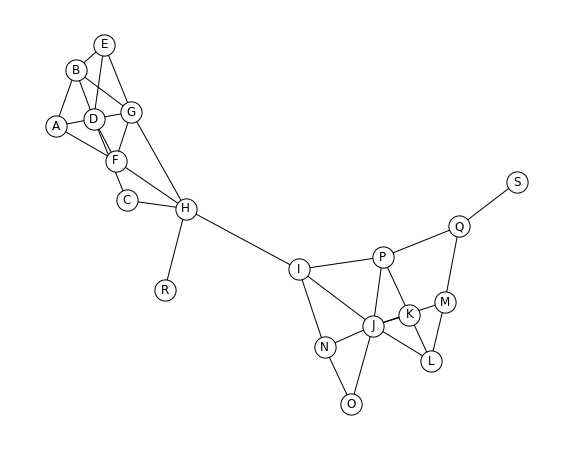

In [243]:
# VISUALIZZAZIONE FORCE-DIRECTED (A CAMPO DI FORZA)
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.axis('off')

# output network
nx.draw_networkx(Ge, pos=nx.spring_layout(Ge, seed=SEED),**BASE_OPTIONS, ax=ax)

### 1.3 LAYOUT FORCE-DIRECTED WEIGTHED

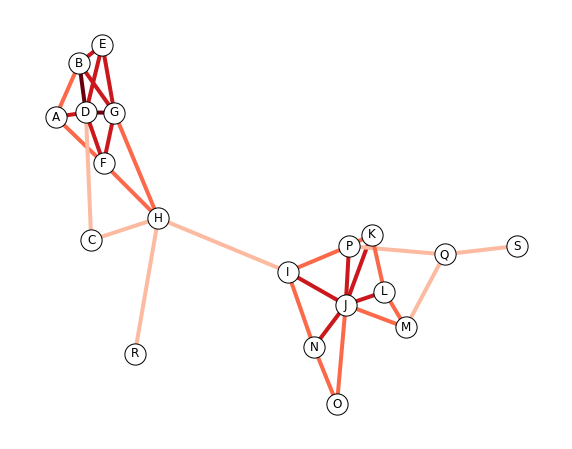

In [245]:
# VISUALIZZAZIONE FORCE-DIRECTED WEIGHTED
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.axis('off')

# funzione per calcolare la forza del legame tra nodi
# basato sul numero di vicini in comune tra i nodi
# presi in considerazione
def tie_strength(G, v, w):
    v_neighbors = set(G.neighbors(v))
    w_neighbors = set(G.neighbors(w))
    return 1 + len(v_neighbors & w_neighbors)

# calcola i pesi da assegnare ai legami
weigths = dict(map(lambda e: (e, tie_strength(Ge, *e)), Ge.edges))
nx.set_edge_attributes(Ge, weigths, "weight")
edge_weights = nx.get_edge_attributes(Ge, "weight").values()

# output network
# colore più scuro = legame più forte
pos = nx.spring_layout(Ge, seed=SEED)
nx.draw_networkx(Ge, pos=pos, **BASE_OPTIONS, ax=ax)
nx.draw_networkx_edges(Ge, pos=pos, width=4, edge_color=edge_weights, edge_cmap=plt.cm.Reds,
    edge_vmin=0, edge_vmax=4, alpha=1, ax=ax);

## 2. DESCRITTIVE: macro-struttura

### 2.1 Diameter
the diameter of a connected graph is the maximum length of a shortest path. That is, it is the maximum of the distances between pairs of vertices in the graph. If the graph has weights on its edges, then its weighted diameter measures path length by the sum of the edge weights along a path, while the unweighted diameter measures path length by the number of edges. For disconnected graphs, definitions vary: the diameter may be defined as infinite, or as the largest diameter of a connected component, or it may be undefined.

In [203]:
diameter = nx.diameter(Ge)
f"diametro del network: {diameter}"

'diametro del network: 6'

{'A': {'A': 0,
  'B': 1,
  'D': 1,
  'F': 1,
  'E': 2,
  'C': 2,
  'H': 2,
  'G': 2,
  'R': 3,
  'I': 3,
  'N': 4,
  'P': 4,
  'J': 4,
  'Q': 5,
  'M': 5,
  'L': 5,
  'O': 5,
  'K': 5,
  'S': 6},
 'B': {'B': 0,
  'A': 1,
  'D': 1,
  'E': 1,
  'G': 1,
  'C': 2,
  'H': 2,
  'F': 2,
  'R': 3,
  'I': 3,
  'N': 4,
  'P': 4,
  'J': 4,
  'Q': 5,
  'M': 5,
  'L': 5,
  'O': 5,
  'K': 5,
  'S': 6},
 'D': {'D': 0,
  'A': 1,
  'E': 1,
  'C': 1,
  'B': 1,
  'F': 1,
  'G': 1,
  'H': 2,
  'I': 3,
  'R': 3,
  'N': 4,
  'P': 4,
  'J': 4,
  'Q': 5,
  'M': 5,
  'L': 5,
  'O': 5,
  'K': 5,
  'S': 6},
 'F': {'F': 0,
  'A': 1,
  'D': 1,
  'H': 1,
  'G': 1,
  'E': 2,
  'C': 2,
  'R': 2,
  'B': 2,
  'I': 2,
  'N': 3,
  'J': 3,
  'P': 3,
  'Q': 4,
  'M': 4,
  'L': 4,
  'O': 4,
  'K': 4,
  'S': 5},
 'E': {'E': 0,
  'B': 1,
  'D': 1,
  'G': 1,
  'A': 2,
  'C': 2,
  'H': 2,
  'F': 2,
  'R': 3,
  'I': 3,
  'N': 4,
  'P': 4,
  'J': 4,
  'Q': 5,
  'M': 5,
  'L': 5,
  'O': 5,
  'K': 5,
  'S': 6},
 'G': {'G': 0,
  'E'

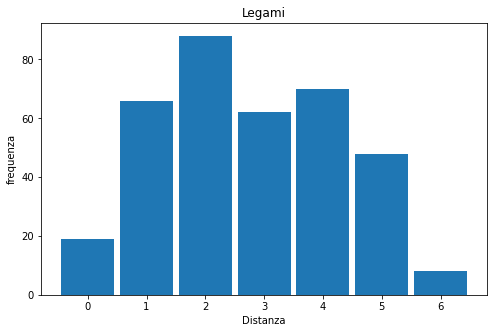

In [235]:
fig, ax = plt.subplots(figsize=(8,5))

# dict lunghezza geodetiche
dict_shortest = dict(nx.shortest_path_length(Ge))

# appittisci dict geodetiche
flattened_shortest = sum(map(lambda x: list(x.values()), dict_shortest.values()),[])

# percorso breve più lungo
high = max(flattened_shortest)

# disegna grafico
bins = [-0.5 + i for i in range(high + 2)]
plt.hist(flattened_shortest, bins=bins, rwidth=.9)
plt.title("Legami")
plt.xlabel("Distanza")
plt.ylabel("frequenza");
dict_shortest

In [170]:
# PERCORSI PIU' LUNGHI
df = pd.DataFrame(nx.shortest_path(G)).applymap(lambda x: len(x))
df["max"] = df.max(axis=1)
df.sort_values(by="max", ascending=False)\
    .head(10)\
    .style.highlight_max(color = 'lightgreen', axis=1, subset=df.columns[:-1])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,max
26,4,4,4,4,5,5,5,5,3,3,5,5,5,3,3,3,6,5,3,3,3,5,3,3,4,4,1,3,3,2,3,3,3,2,6
29,4,4,3,4,5,5,5,4,3,3,5,5,5,3,3,3,6,5,3,3,3,5,3,2,4,3,2,3,3,1,3,3,2,2,6
22,4,4,3,4,5,5,5,4,3,3,5,5,5,3,3,3,6,5,3,3,3,5,1,3,4,4,3,3,3,3,3,3,2,2,6
20,4,4,3,4,5,5,5,4,3,3,5,5,5,3,3,3,6,5,3,3,1,5,3,3,4,4,3,3,3,3,3,3,2,2,6
18,4,4,3,4,5,5,5,4,3,3,5,5,5,3,3,3,6,5,1,3,3,5,3,3,4,4,3,3,3,3,3,3,2,2,6
15,4,4,3,4,5,5,5,4,3,3,5,5,5,3,3,1,6,5,3,3,3,5,3,3,4,4,3,3,3,3,3,3,2,2,6
14,4,4,3,4,5,5,5,4,3,3,5,5,5,3,1,3,6,5,3,3,3,5,3,3,4,4,3,3,3,3,3,3,2,2,6
23,4,4,3,4,5,5,5,4,3,3,5,5,5,3,3,3,6,5,3,3,3,5,3,1,3,2,3,2,3,2,3,3,2,2,6
16,3,4,4,4,3,2,2,4,4,5,3,4,4,4,6,6,1,4,6,4,6,4,6,6,5,5,6,5,5,6,5,4,5,5,6
9,3,3,2,3,4,4,4,3,3,1,4,4,4,3,3,3,5,4,3,3,3,4,3,3,4,4,3,3,3,3,3,3,3,2,5


[[29, 32, 2, 0, 5, 16],
 [29, 32, 8, 0, 5, 16],
 [29, 33, 8, 0, 5, 16],
 [29, 32, 31, 0, 5, 16],
 [29, 33, 31, 0, 5, 16],
 [29, 33, 13, 0, 5, 16],
 [29, 33, 19, 0, 5, 16],
 [29, 32, 2, 0, 6, 16],
 [29, 32, 8, 0, 6, 16],
 [29, 33, 8, 0, 6, 16],
 [29, 32, 31, 0, 6, 16],
 [29, 33, 31, 0, 6, 16],
 [29, 33, 13, 0, 6, 16],
 [29, 33, 19, 0, 6, 16]]

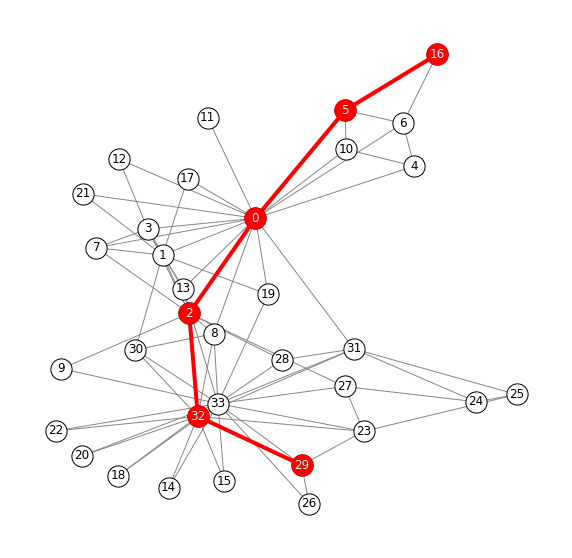

In [171]:
# ESEMPIO DI PERCORSO LUNGO
fig, ax = plot_default_spring(G,SL);

s_node = 29
t_node = 16

possible_sp = list(nx.all_shortest_paths(G,s_node, t_node))

display(possible_sp)

first_sp = possible_sp[0]
first_sp_edges = [ (x, first_sp[idx+1]) for idx,x in enumerate(first_sp[:-1]) ]

nx.draw_networkx_nodes(
    G, SL, nodelist=first_sp, node_size=NODE_SIZE, node_color= "r", edgecolors="r", ax=ax)
nx.draw_networkx_edges(G, SL, edgelist=first_sp_edges, edge_color="r", width=4, ax=ax)
nx.draw_networkx_labels(G, SL, labels=dict([(e,e) for e in first_sp]), font_color="#fff");

### 2.2 DENSITY
In a graph of n nodes, the density is the ratio of the number of edges of the graph to the number of edges in a complete graph on n nodes.

In [172]:
density = nx.density(G)
f"density: {density}"

'density: 0.13903743315508021'

### 2.3 CENTRALIZATION

In [173]:
def get_centralization(G):
    n = G.order()
    centrality_values = dict(G.degree()).values()
    c_max = max(centrality_values)
    return sum([ c_max - value for value in centrality_values ]) / ((n-1)*(n-2))

f"centralizzazione: {get_centralization(G)}"

'centralizzazione: 0.3996212121212121'

'centralizzazione: 1.0'

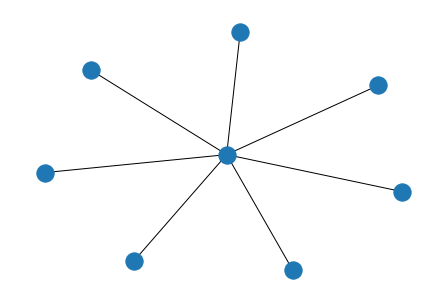

In [174]:
# ESEMPIO DI CENTRALIZATION MASSIMA
S = nx.Graph()
S.add_nodes_from(range(8))
nx.add_star(S, S.nodes())
loc = nx.spring_layout(S)
nx.draw(S,loc)

f"centralizzazione: {get_centralization(S)}"

'centralizzazione: 0.0'

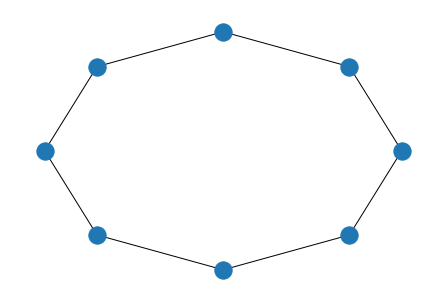

In [175]:
# ESEMPIO DI CENTRALIZATION MINIMA
C = nx.Graph()
nodes = range(8)
C.add_nodes_from(nodes)
C.add_edges_from(
    sum([[(x,nodes[idx+1]) for idx,x in enumerate(nodes[:-1])], [(nodes[0], nodes[-1])]], [])
)
loc = nx.circular_layout(C)
nx.draw(C,loc)

f"centralizzazione: {get_centralization(C)}"

### 2.4 GLOBAL CLUSTERING

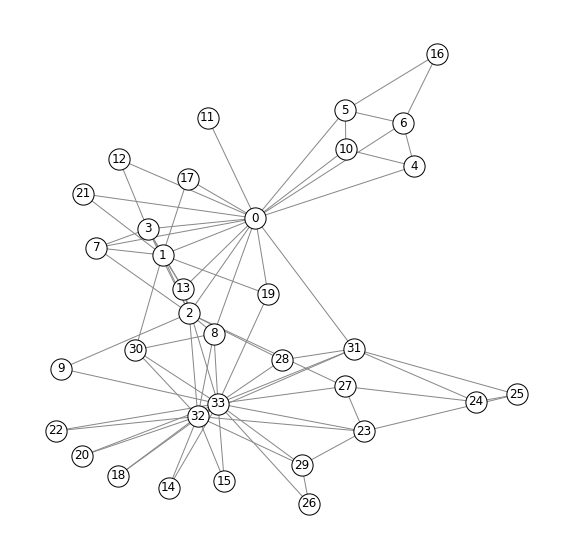

In [176]:
fig, ax = plot_default_spring(G,SL)

In [177]:
global_clustering = nx.average_clustering(G)

f"global clustering: {global_clustering}"
nx.transitivity(G)

0.2556818181818182

'global clustering: 1.0'

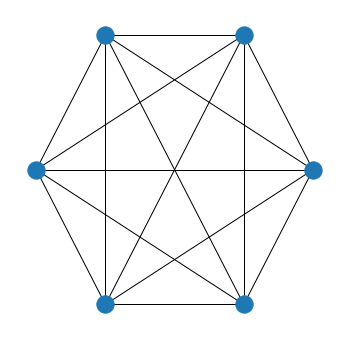

In [178]:
# ESEMPIO DI NETWORK COMPLETO
fig, ax = plt.subplots(figsize=(6,6))
ax.axis('off')

G_complete = nx.complete_graph(6)
pos = nx.circular_layout(G_complete)
nx.draw_networkx(G_complete, pos=pos, with_labels=False, ax=ax)
f"global clustering: {nx.average_clustering(G_complete)}"

f"global clustering: {nx.average_clustering(G_complete)}"

'global clustering: 0.0'

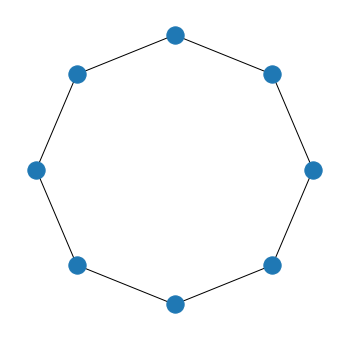

In [179]:
fig, ax = plt.subplots(figsize=(6,6))
ax.axis('off')

G_small_ring = nx.watts_strogatz_graph(8, 2, 0)
pos = nx.circular_layout(G_small_ring)
nx.draw_networkx(G_small_ring, pos=pos, with_labels=False, ax=ax)
f"global clustering: {nx.average_clustering(G_small_ring)}"

# 2. DESCRITTIVE: micro-strutture

<b>Degree cenrality</b> the number of links incident upon a node (i.e., the number of ties that a node has)

In [180]:
highest_dc = [ n for n,v in sorted(list(nx.degree(G)), key=lambda e: e[1])[-10:]]
f"I 10 nodi con più alta dc: {highest_dc}"

'I 10 nodi con più alta dc: [8, 13, 23, 3, 31, 1, 2, 32, 0, 33]'

<b>Bridge</b>:  a bridge, isthmus, cut-edge, or cut arc is an edge of a graph whose deletion increases the graph's number of connected components.

In [181]:
bridges = list(nx.bridges(G))
f"bridges: {bridges}"

'bridges: [(0, 11)]'

In [182]:
# proof
G_clone = G.copy()
cc_before = len(list(nx.connected_components(G_clone)))
display(f"connected components before bridge removal: {cc_before}")
G_clone.remove_edge(*bridges[0])
cc_after = len(list(nx.connected_components(G_clone)))
display(f"connected components before bridge removal: {cc_after}")

'connected components before bridge removal: 1'

'connected components before bridge removal: 2'

# 3. DESCRITTIVE: meso-strutture

### Ricerca comunità (Clauset-Newman-Moore greedy modularity maximization)

In [183]:
communities = sorted(nxcomm.greedy_modularity_communities(G), key=len)

f"{len(communities)} comunità trovate"

'3 comunità trovate'

In [184]:
(c1, c2, c3) = nxcomm.greedy_modularity_communities(G)

display(f"C1: {c1}")
display(f"C2: {c2}")
display(f"C3: {c3}")

'C1: frozenset({8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33})'

'C2: frozenset({1, 2, 3, 7, 9, 12, 13, 17, 21})'

'C3: frozenset({0, 16, 19, 4, 5, 6, 10, 11})'

In [185]:
c1_with_c2 = set(sum([list(G.neighbors(n)) for n in c2], [])).intersection(c1)
c1_with_c3 = set(sum([list(G.neighbors(n)) for n in c3], [])).intersection(c1)
c2_with_c3 = set(sum([list(G.neighbors(n)) for n in c3], [])).intersection(c2)

display(f"nodi di collegamento C1 e C2 {c1_with_c2}")
display(f"nodi di collegamento C1 e C3 {c1_with_c3}")
display(f"nodi di collegamento C2 e C3 {c2_with_c3}")

'nodi di collegamento C1 e C2 {32, 33, 8, 27, 28, 30}'

'nodi di collegamento C1 e C3 {8, 33, 31}'

'nodi di collegamento C2 e C3 {1, 2, 3, 7, 12, 13, 17, 21}'

In [186]:
c1_with_c2 = set(sum([list(G.neighbors(n)) for n in c2], [])).intersection(c1)
c1_with_c3 = set(sum([list(G.neighbors(n)) for n in c3], [])).intersection(c1)
c2_with_c3 = set(sum([list(G.neighbors(n)) for n in c3], [])).intersection(c2)

display(f"nodi di collegamento C1 e C2 {c1_with_c2}")
display(f"nodi di collegamento C1 e C3 {c1_with_c3}")
display(f"nodi di collegamento C2 e C3 {c2_with_c3}")

'nodi di collegamento C1 e C2 {32, 33, 8, 27, 28, 30}'

'nodi di collegamento C1 e C3 {8, 33, 31}'

'nodi di collegamento C2 e C3 {1, 2, 3, 7, 12, 13, 17, 21}'

In [187]:
comm_officer = list(c1)
comm_mrhi = list(c2) + list(c3)

e_0 = [0 if G.nodes()[n]['club'] == "Mr. Hi" else 1 for n in comm_mrhi]
e_1 = [0 if G.nodes()[n]['club'] == "Officer" else 1 for n in comm_officer]

hit_perc = 1 - sum((e_0 + e_1))/G.order()

f"percentuale di successo: {hit_perc}"

display(c1, c2, c3)

frozenset({8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33})

frozenset({1, 2, 3, 7, 9, 12, 13, 17, 21})

frozenset({0, 4, 5, 6, 10, 11, 16, 19})